In [7]:
import rasterio
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

ruta_ndvi = "/home/camilo/Documentos/nvid.tif"  
salida_shp = "/home/camilo/Documentos/puntos_ndvi.shp"
umbral_min = 0.6   # Valor mínimo NDVI (cultivos sanos valores tomados de pdf referecnicia )
umbral_max = 1.0   # Valor máximo NDVI

# abrir
with rasterio.open(ruta_ndvi) as src:
    ndvi = src.read(1)  # primera banda
    perfil = src.profile

# detectar y cionvertir
mask = (ndvi >= umbral_min) & (ndvi <= umbral_max)

rows, cols = np.where(mask)
coords = [src.xy(row, col) for row, col in zip(rows, cols)]

# crear shp
gdf = gpd.GeoDataFrame(geometry=[Point(x, y) for x, y in coords],
                       crs=perfil['crs'])
gdf.to_file(salida_shp)

print(f"Shapefile creado con {len(gdf)} puntos: {salida_shp}")


Shapefile creado con 411577 puntos: /home/camilo/Documentos/puntos_ndvi.shp


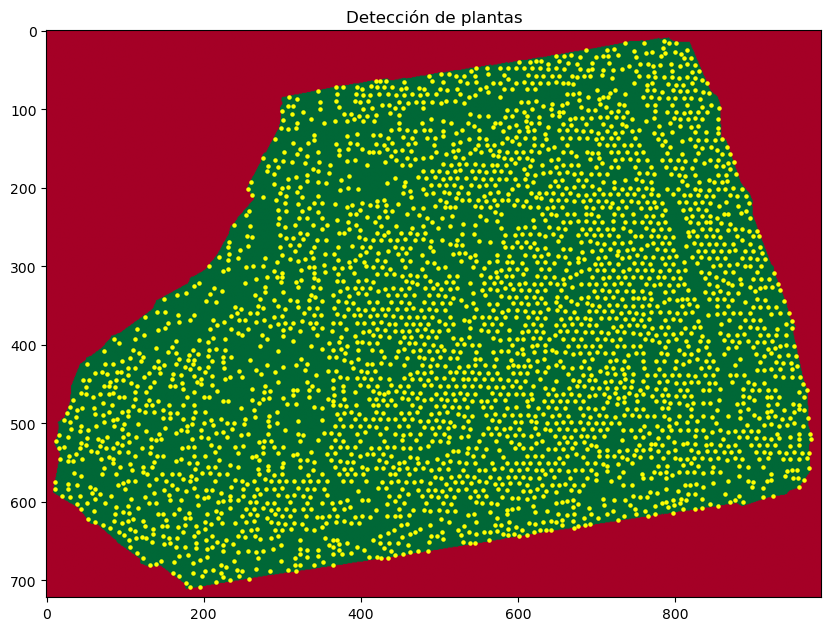

In [9]:

import rasterio
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from skimage.feature import peak_local_max
from skimage.morphology import remove_small_objects, binary_opening, disk
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

#cargar el raster
raster_path = "/home/camilo/Documentos/nvid.tif"  
with rasterio.open(raster_path) as src:
    ndvi = src.read(1)  # Primera banda
    profile = src.profile

# calcular umbral automático (Otsu) para separar vegetación.
thresh = threshold_otsu(ndvi)
veg_mask = ndvi > thresh

# Limpiar ruido con morfología 
veg_mask = remove_small_objects(veg_mask, min_size=20)  # Elimina manchas pequeñas
veg_mask = binary_opening(veg_mask, disk(2))  # Suaviza

#  centros de plantas
coords = peak_local_max(ndvi, min_distance=5, labels=veg_mask)

# Convertir coordenadas de píxeles a coordenadas geográficas 
points = []
for row, col in coords:
    x, y = src.xy(row, col)
    points.append(Point(x, y))

# Crear GDF y exportar
gdf = gpd.GeoDataFrame(geometry=points, crs=profile["crs"])
gdf.to_file("detecciones.shp")
gdf.to_csv("detecciones.csv", index=False)

#salida grafica.
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(ndvi, cmap="RdYlGn")
plt.scatter(coords[:, 1], coords[:, 0], c='yellow', s=5)
plt.title("Detección de plantas")
plt.show()

